In [ ]:
!pip install pandas numpy matplotlib scipy

Loaded CSV files: ['Potencia Contador Energía Calderas Gas (15 minuto).csv', 'Tª Impulsión Caldera gas 1 (15 minuto).csv', 'Tª Retorno Contador Energía Fase 1 Central.csv', 'Energía Contador Energía Fase 2 Central.csv', 'Potencia Contador Energía Fase 2 (15 minuto).csv', 'TEMPERATURA IMPULS FASE II (15 minuto).csv', 'Energía Contador Energía Fase 1 Central.csv', 'Tª Retorno Contador Energía Fase 2 Central (15 minuto).csv']


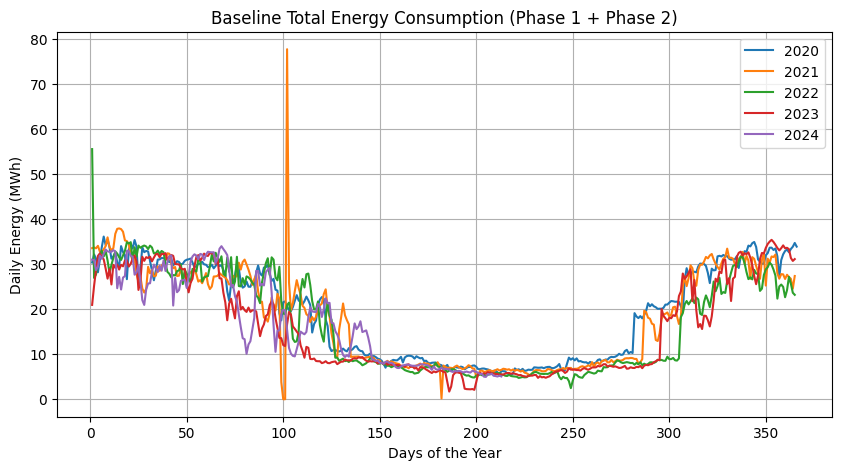

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CONFIG
# ==============================
YEARS = [2020, 2021, 2022, 2023, 2024]

VAR_F1 = "Energía Contador Energía Fase 1 Central"
VAR_F2 = "Energía Contador Energía Fase 2 Central"

# ==============================
# 1️⃣ LOAD CSVs
# ==============================
files = [f for f in os.listdir() if f.endswith(".csv")]
print("Loaded CSV files:", files)

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.lower().str.strip()
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = df[df["fecha"].dt.year.isin(YEARS)]

# ==============================
# 2️⃣ FILTER PHASE 1 & PHASE 2
# ==============================
f1 = df[df["variable"].str.contains(VAR_F1, case=False, na=False)].copy()
f2 = df[df["variable"].str.contains(VAR_F2, case=False, na=False)].copy()

f1 = f1.sort_values("fecha")
f2 = f2.sort_values("fecha")

# ==============================
# 3️⃣ HANDLE CUMULATIVE VARIABLE (DIFF)
# ==============================
f1["energy_f1"] = f1["valor"].diff()
f2["energy_f2"] = f2["valor"].diff()

f1 = f1[f1["energy_f1"] >= 0]
f2 = f2[f2["energy_f2"] >= 0]

# ==============================
# 4️⃣ MERGE TOTAL ENERGY
# ==============================
energy = pd.merge(
    f1[["fecha","energy_f1"]],
    f2[["fecha","energy_f2"]],
    on="fecha",
    how="inner"
)

energy["total_energy"] = energy["energy_f1"] + energy["energy_f2"]

# ==============================
# 5️⃣ DAILY BASELINE
# ==============================
daily = (
    energy.set_index("fecha")["total_energy"]
    .resample("1D").sum()
    .reset_index()
)

daily["year"] = daily["fecha"].dt.year
daily["day_of_year"] = daily["fecha"].dt.dayofyear

# ==============================
# 6️⃣ PLOT BASELINE
# ==============================
plt.figure(figsize=(10,5))

for y in YEARS:
    temp = daily[daily["year"] == y]
    plt.plot(temp["day_of_year"], temp["total_energy"], label=str(y))

plt.title("Baseline Total Energy Consumption (Phase 1 + Phase 2)")
plt.xlabel("Days of the Year")
plt.ylabel("Daily Energy (MWh)")
plt.legend()
plt.grid(True)
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 1089, number of used features: 3
[LightGBM] [Info] Start training from score 18.120771
Forecast MAE: 2.38


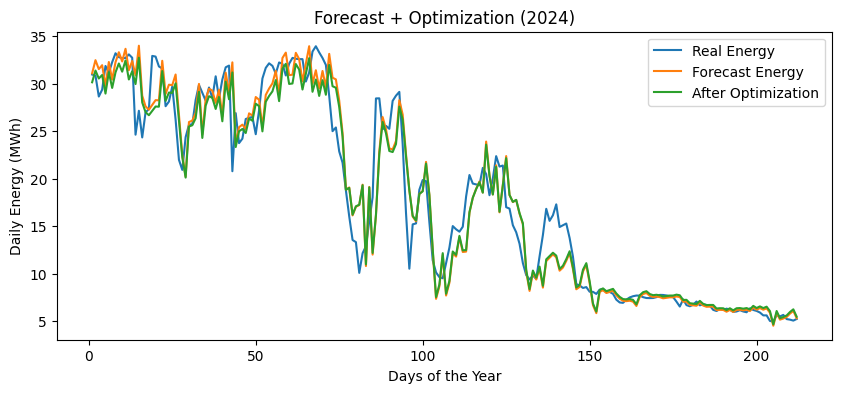

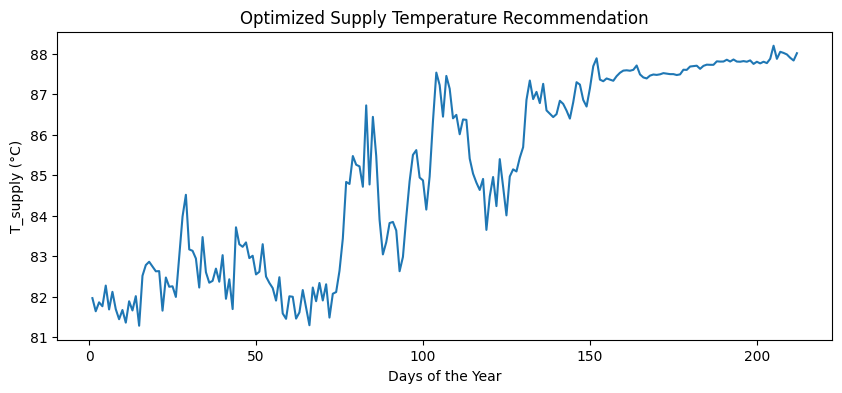

Estimated Energy Savings (%): 1.26


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# ===================================
# 1️⃣ PREPARE DATA
# ===================================

data = daily.copy()

data["target"] = data["total_energy"].shift(-1)

# features simples
data["lag_1"] = data["total_energy"].shift(1)
data["lag_7"] = data["total_energy"].shift(7)
data["rolling_7"] = data["total_energy"].rolling(7).mean()

data = data.dropna()

train = data[data["year"] <= 2022]
test  = data[data["year"] == 2024]

X_train = train[["lag_1","lag_7","rolling_7"]]
y_train = train["target"]

X_test = test[["lag_1","lag_7","rolling_7"]]
y_test = test["target"]

# ===================================
# 2️⃣ TRAIN FORECAST MODEL
# ===================================

model = LGBMRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

forecast = model.predict(X_test)

mae = mean_absolute_error(y_test, forecast)
print("Forecast MAE:", round(mae,2))

test = test.copy()
test["forecast_energy"] = forecast

# ===================================
# 3️⃣ OPTIMIZATION LOGIC
# ===================================

T_BASE = 85      # baseline supply temp
T_MIN = 70
T_MAX = 95
ALPHA = 0.05     # sensitivity factor

mean_energy = train["total_energy"].mean()

test["optimized_T_supply"] = (
    T_BASE - ALPHA * ((test["forecast_energy"] - mean_energy) / mean_energy) * T_BASE
)

# clamp limits
test["optimized_T_supply"] = test["optimized_T_supply"].clip(T_MIN, T_MAX)

# ===================================
# 4️⃣ ESTIMATED ENERGY SAVINGS
# ===================================

# simple proxy: assume 1% energy reduction per °C reduced
delta_T = T_BASE - test["optimized_T_supply"]
test["estimated_energy_after_opt"] = test["forecast_energy"] * (1 - 0.01 * delta_T)

# ===================================
# 5️⃣ PLOTS
# ===================================

plt.figure(figsize=(10,4))
plt.plot(test["day_of_year"], test["total_energy"], label="Real Energy")
plt.plot(test["day_of_year"], test["forecast_energy"], label="Forecast Energy")
plt.plot(test["day_of_year"], test["estimated_energy_after_opt"], label="After Optimization")
plt.title("Forecast + Optimization (2024)")
plt.xlabel("Days of the Year")
plt.ylabel("Daily Energy (MWh)")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(test["day_of_year"], test["optimized_T_supply"])
plt.title("Optimized Supply Temperature Recommendation")
plt.xlabel("Days of the Year")
plt.ylabel("T_supply (°C)")
plt.show()

# ===================================
# 6️⃣ SAVINGS KPI
# ===================================

baseline_total = test["forecast_energy"].sum()
optimized_total = test["estimated_energy_after_opt"].sum()

savings = (baseline_total - optimized_total) / baseline_total * 100

print("Estimated Energy Savings (%):", round(savings,2))

In [ ]:
!pip install tensorflow

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0202
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0038
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0013
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0016
Epoch 9/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017
Epoch 10/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019
Epoch 11/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014
Epoch 12/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012
Epoch 13/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011
Epoch 14/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 15/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019
Epoc

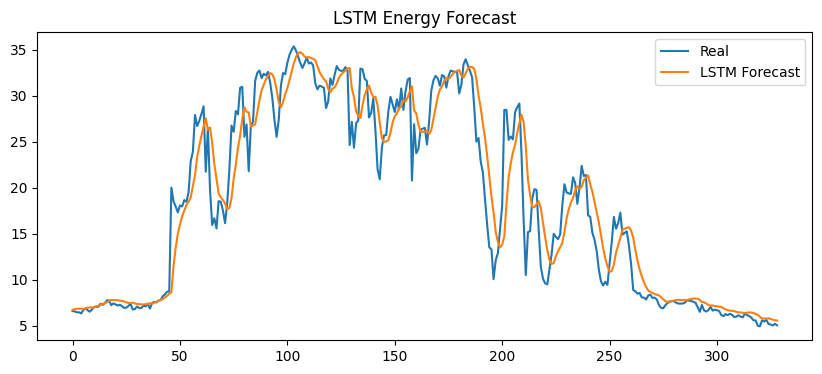

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ==================================
# 1️⃣ PREPARE DAILY DATA
# ==================================

data = daily.copy()
series = data["total_energy"].values.reshape(-1,1)

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

# create sequences
LOOKBACK = 30

X = []
y = []

for i in range(LOOKBACK, len(series_scaled)):
    X.append(series_scaled[i-LOOKBACK:i])
    y.append(series_scaled[i])

X = np.array(X)
y = np.array(y)

# split train/test
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==================================
# 2️⃣ BUILD LSTM MODEL
# ==================================

model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(LOOKBACK,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# ==================================
# 3️⃣ TRAIN
# ==================================

model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

# ==================================
# 4️⃣ PREDICT
# ==================================

pred = model.predict(X_test)

pred_rescaled = scaler.inverse_transform(pred)
y_test_rescaled = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_rescaled, pred_rescaled)
print("LSTM MAE:", round(mae,2))

# ==================================
# 5️⃣ PLOT
# ==================================

plt.figure(figsize=(10,4))
plt.plot(y_test_rescaled, label="Real")
plt.plot(pred_rescaled, label="LSTM Forecast")
plt.title("LSTM Energy Forecast")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

FILE_F1 = "Energía Contador Energía Fase 1 Central.csv"
FILE_F2 = "Energía Contador Energía Fase 2 Central.csv"

df1 = pd.read_csv(FILE_F1)
df2 = pd.read_csv(FILE_F2)

print("F1 columns:", df1.columns.tolist())
print(df1.head(5))

print("\nF2 columns:", df2.columns.tolist())
print(df2.head(5))

import pandas as pd
import numpy as np

FILE_F1 = "Energía Contador Energía Fase 1 Central.csv"
FILE_F2 = "Energía Contador Energía Fase 2 Central.csv"

def load_energy_fixed(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()

    # fecha
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # valor con coma decimal
    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    df = df.dropna(subset=["fecha","valor"]).sort_values("fecha")
    return df[["fecha","valor"]]

# 1) cargar acumuladas
f1 = load_energy_fixed(FILE_F1).rename(columns={"valor":"e_f1"})
f2 = load_energy_fixed(FILE_F2).rename(columns={"valor":"e_f2"})

# 2) merge
energy = pd.merge(f1, f2, on="fecha", how="inner").sort_values("fecha")

# 3) total acumulado
energy["total_acc"] = energy["e_f1"] + energy["e_f2"]

# 4) diff (energía del intervalo)
energy["interval_energy"] = energy["total_acc"].diff()

# 5) quitar resets
energy = energy.dropna(subset=["interval_energy"])
energy = energy[energy["interval_energy"] >= 0]

# 6) diario
daily = (
    energy.set_index("fecha")[["interval_energy"]]
    .resample("1D")
    .sum()
    .dropna()
    .reset_index()
).rename(columns={"interval_energy":"total_daily_energy"})

print(daily.head(10))
print("\nDescribe:")
print(daily["total_daily_energy"].describe(percentiles=[0.05,0.25,0.50,0.75,0.95]))


print(df1.columns.tolist())
print(df1.head(3))

F1 columns: ['endpoint', 'id', 'variable', 'fecha', 'valor']
                       endpoint    id  \
0  EDEN1D - M028309 - TORRELAGO  4078   
1  EDEN1D - M028309 - TORRELAGO  4078   
2  EDEN1D - M028309 - TORRELAGO  4078   
3  EDEN1D - M028309 - TORRELAGO  4078   
4  EDEN1D - M028309 - TORRELAGO  4078   

                                  variable                    fecha  \
0  Energía Contador Energía Fase 1 Central  2020-01-01 00:00:00.000   
1  Energía Contador Energía Fase 1 Central  2020-01-01 00:15:00.000   
2  Energía Contador Energía Fase 1 Central  2020-01-01 00:30:00.000   
3  Energía Contador Energía Fase 1 Central  2020-01-01 00:45:00.000   
4  Energía Contador Energía Fase 1 Central  2020-01-01 01:00:00.000   

        valor  
0    24510,00  
1    24510,10  
2    24510,20  
3    24510,20  
4    24510,30  

F2 columns: ['endpoint', 'id', 'variable', 'fecha', 'valor']
                       endpoint    id  \
0  EDEN1D - M028309 - TORRELAGO  4082   
1  EDEN1D - M028309 - TOR


=== SUMMARY (Daily Total Energy) ===
                                         count       mean        std  min  \
Total Daily Energy (Phase 1 + Phase 2)  1674.0  17.759468  10.646457  0.0   

                                         p05     p25    p50    p75    p95  \
Total Daily Energy (Phase 1 + Phase 2)  5.42  7.4025  17.51  28.31  32.89   

                                          max  
Total Daily Energy (Phase 1 + Phase 2)  77.65  


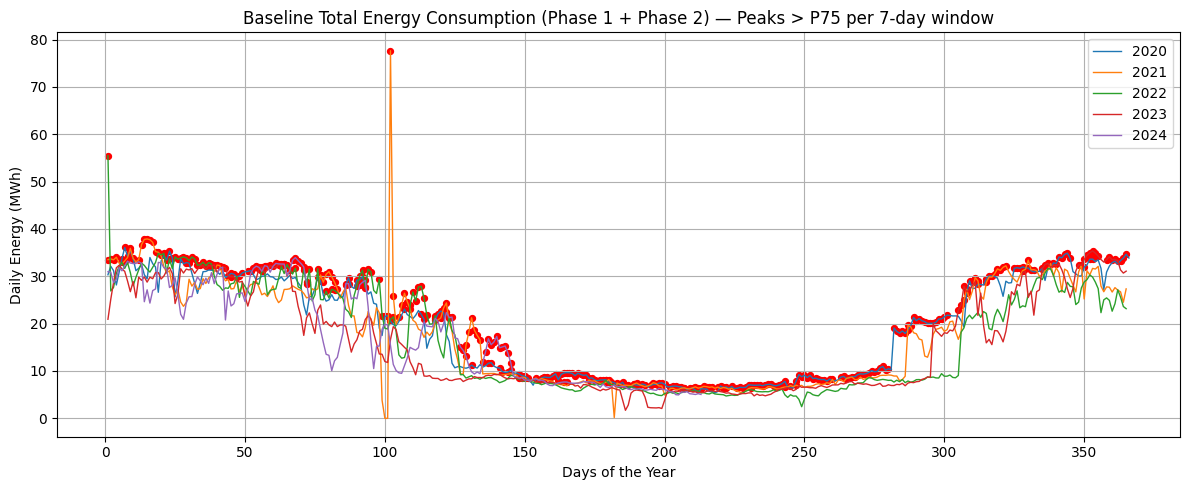

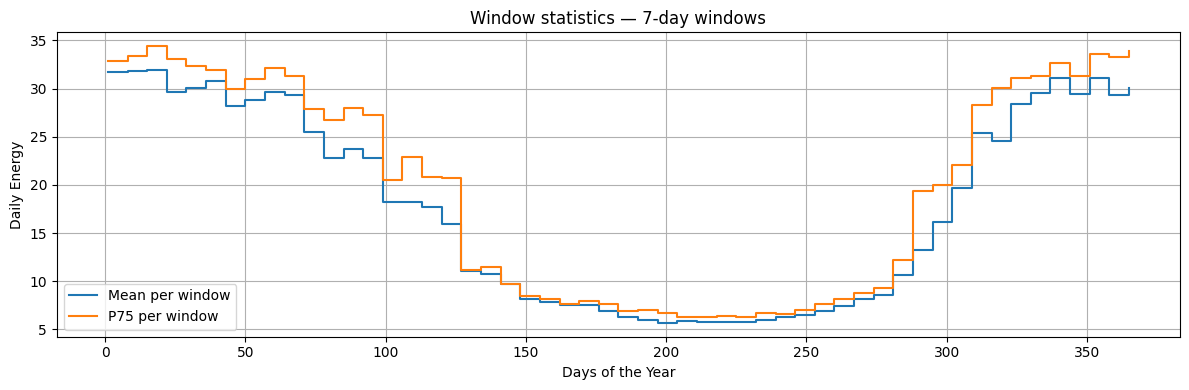

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
FILE_F1 = "Energía Contador Energía Fase 1 Central.csv"
FILE_F2 = "Energía Contador Energía Fase 2 Central.csv"

YEARS = [2020, 2021, 2022, 2023, 2024]
TRAMO_DIAS = 7      # tramos de 7 días (cambia a 14 si quieres)
PERCENTIL = 0.75    # P75

# =========================
# LOAD (tu formato: endpoint,id,variable,fecha,valor)
# =========================
def load_energy_csv_fixed(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()

    # fecha
    if "fecha" not in df.columns:
        raise ValueError(f"Column 'fecha' not found in {path}. Found: {df.columns.tolist()}")
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # valor (coma decimal)
    if "valor" not in df.columns:
        raise ValueError(f"Column 'valor' not found in {path}. Found: {df.columns.tolist()}")
    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    df = df.dropna(subset=["fecha", "valor"]).sort_values("fecha")
    return df[["fecha", "valor"]].copy()

# =========================
# 1) Load acumuladas
# =========================
f1 = load_energy_csv_fixed(FILE_F1).rename(columns={"valor": "e_f1"})
f2 = load_energy_csv_fixed(FILE_F2).rename(columns={"valor": "e_f2"})

# =========================
# 2) Merge + total acumulado
# =========================
energy = pd.merge(f1, f2, on="fecha", how="inner").sort_values("fecha")
energy["total_acc"] = energy["e_f1"] + energy["e_f2"]

# =========================
# 3) Acumulado -> intervalo (diff)
# =========================
energy["interval_energy"] = energy["total_acc"].diff()
energy = energy.dropna(subset=["interval_energy"])

# quitar resets (negativos)
energy = energy[energy["interval_energy"] >= 0]

# =========================
# 4) Diario
# =========================
daily = (
    energy.set_index("fecha")[["interval_energy"]]
    .resample("1D")
    .sum()
    .dropna()
    .reset_index()
).rename(columns={"interval_energy": "total_daily_energy"})

daily["year"] = daily["fecha"].dt.year
daily = daily[daily["year"].isin(YEARS)].copy()
daily["day_of_year"] = daily["fecha"].dt.dayofyear

# =========================
# 5) TABLA resumen (sobre energía diaria total)
# =========================
summary = daily["total_daily_energy"].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).to_frame().T
summary.index = ["Total Daily Energy (Phase 1 + Phase 2)"]

summary = summary.rename(columns={
    "count":"count","mean":"mean","std":"std","min":"min",
    "5%":"p05","25%":"p25","50%":"p50","75%":"p75","95%":"p95","max":"max"
})
print("\n=== SUMMARY (Daily Total Energy) ===")
print(summary)

# =========================
# 6) Tramos + media + P75 por tramo (global)
# =========================
daily["tramo"] = ((daily["day_of_year"] - 1) // TRAMO_DIAS).astype(int)

stats_tramo = daily.groupby("tramo")["total_daily_energy"].agg(
    mean_tramo="mean",
    p75_tramo=lambda x: x.quantile(PERCENTIL)
).reset_index()

daily = daily.merge(stats_tramo, on="tramo", how="left")
daily["is_peak"] = daily["total_daily_energy"] > daily["p75_tramo"]

# =========================
# 7) GRÁFICA baseline por años + picos rojos (como la primera)
# =========================
plt.figure(figsize=(12,5))

for y in sorted(daily["year"].unique()):
    temp = daily[daily["year"] == y]
    plt.plot(temp["day_of_year"], temp["total_daily_energy"], label=str(y), linewidth=1)

    peaks = temp[temp["is_peak"]]
    plt.scatter(peaks["day_of_year"], peaks["total_daily_energy"], color="red", s=18)

plt.title(f"Baseline Total Energy Consumption (Phase 1 + Phase 2) — Peaks > P{int(PERCENTIL*100)} per {TRAMO_DIAS}-day window")
plt.xlabel("Days of the Year")
plt.ylabel("Daily Energy (MWh)")  # (si tu contador está en kWh, dime y lo convierto)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# (Opcional) escalones de media y P75 por tramo
# =========================
x = (stats_tramo["tramo"] * TRAMO_DIAS) + 1

plt.figure(figsize=(12,4))
plt.step(x, stats_tramo["mean_tramo"], where="post", label="Mean per window")
plt.step(x, stats_tramo["p75_tramo"], where="post", label=f"P{int(PERCENTIL*100)} per window")
plt.title(f"Window statistics — {TRAMO_DIAS}-day windows")
plt.xlabel("Days of the Year")
plt.ylabel("Daily Energy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

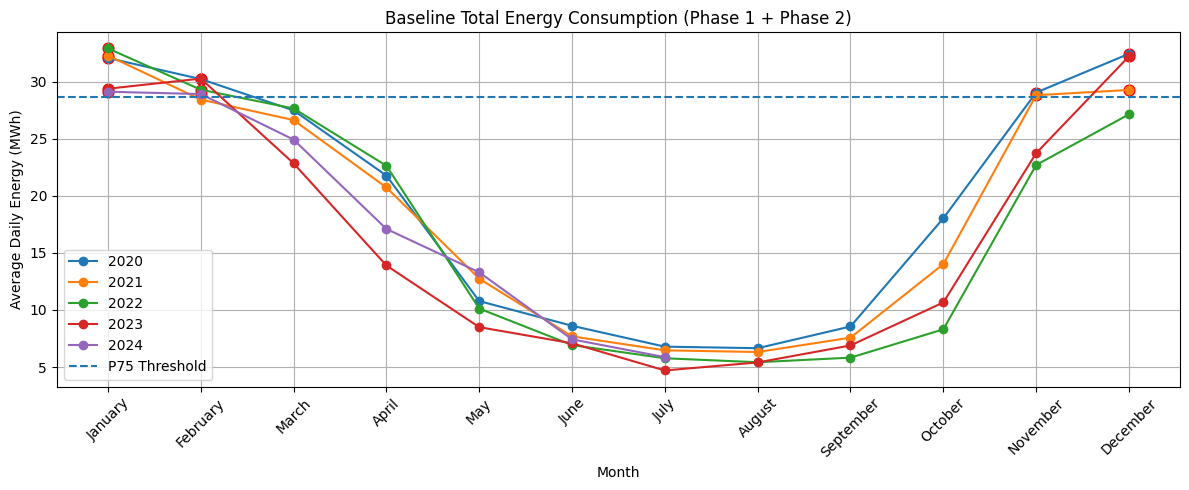

In [ ]:
# =========================
# MONTHLY AGGREGATION
# =========================

daily["month"] = daily["fecha"].dt.month
daily["month_name"] = daily["fecha"].dt.strftime("%B")

monthly = (
    daily.groupby(["year", "month", "month_name"])["total_daily_energy"]
    .mean()
    .reset_index()
)

# Percentil 75 global mensual
p75_month = monthly["total_daily_energy"].quantile(0.75)

monthly["is_peak"] = monthly["total_daily_energy"] > p75_month

# Orden correcto de meses
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly["month_name"] = pd.Categorical(
    monthly["month_name"],
    categories=month_order,
    ordered=True
)

monthly = monthly.sort_values(["year","month"])

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,5))

for y in sorted(monthly["year"].unique()):
    temp = monthly[monthly["year"] == y]
    plt.plot(temp["month_name"], temp["total_daily_energy"], label=str(y), marker="o")

    peaks = temp[temp["is_peak"]]
    plt.scatter(peaks["month_name"], peaks["total_daily_energy"], color="red", s=60)

plt.axhline(p75_month, linestyle="--", label="P75 Threshold")

plt.title("Baseline Total Energy Consumption (Phase 1 + Phase 2)")
plt.xlabel("Month")
plt.ylabel("Average Daily Energy (MWh)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

                 Metric      Value
0   P10 (low threshold)   6.044774
1  P95 (high threshold)  32.226032


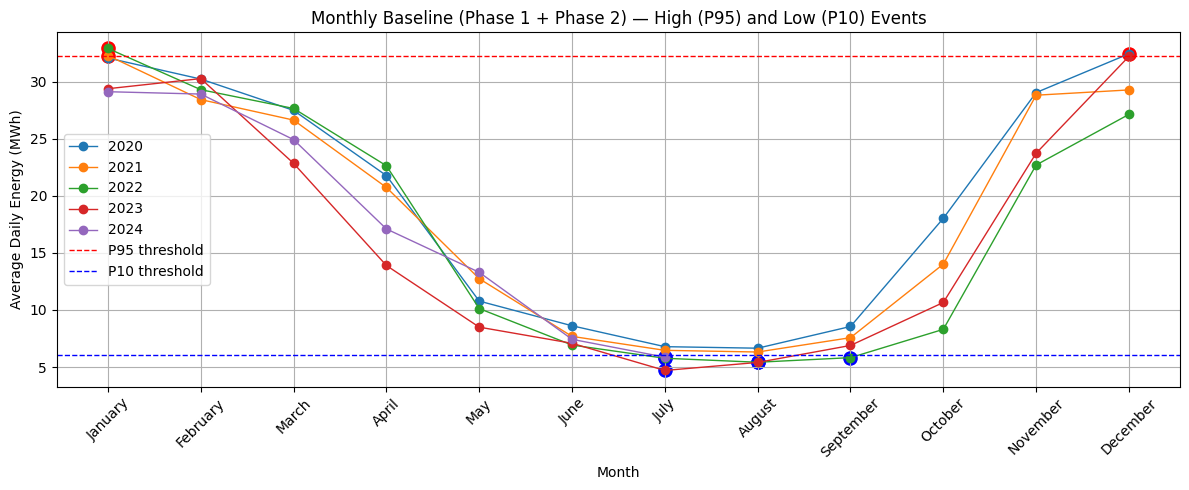

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
P_HIGH = 0.95  # peaks high
P_LOW  = 0.10  # peaks low

# -------------------------
# MONTHLY aggregation (mean daily energy per month)
# -------------------------
daily["month"] = daily["fecha"].dt.month
daily["month_name"] = daily["fecha"].dt.strftime("%B")

monthly = (
    daily.groupby(["year", "month", "month_name"])["total_daily_energy"]
    .mean()
    .reset_index()
)

# thresholds (global over all months)
p95 = float(monthly["total_daily_energy"].quantile(P_HIGH))
p10 = float(monthly["total_daily_energy"].quantile(P_LOW))

monthly["is_high_peak"] = monthly["total_daily_energy"] > p95
monthly["is_low_peak"]  = monthly["total_daily_energy"] < p10

# order months for plotting
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly["month_name"] = pd.Categorical(monthly["month_name"], categories=month_order, ordered=True)
monthly = monthly.sort_values(["year", "month"])

# -------------------------
# PRINT thresholds table
# -------------------------
thr_table = pd.DataFrame({
    "Metric": ["P10 (low threshold)", "P95 (high threshold)"],
    "Value": [p10, p95]
})
print(thr_table)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(12,5))

for y in sorted(monthly["year"].unique()):
    temp = monthly[monthly["year"] == y].copy()

    # line per year
    plt.plot(temp["month_name"], temp["total_daily_energy"], marker="o", linewidth=1, label=str(y))

    # high peaks (red)
    high = temp[temp["is_high_peak"]]
    plt.scatter(high["month_name"], high["total_daily_energy"], color="red", s=90, label="_nolegend_")

    # low peaks (blue)
    low = temp[temp["is_low_peak"]]
    plt.scatter(low["month_name"], low["total_daily_energy"], color="blue", s=90, label="_nolegend_")

# threshold lines
plt.axhline(p95, color="red", linestyle="--", linewidth=1, label="P95 threshold")
plt.axhline(p10, color="blue", linestyle="--", linewidth=1, label="P10 threshold")

plt.title("Monthly Baseline (Phase 1 + Phase 2) — High (P95) and Low (P10) Events")
plt.xlabel("Month")
plt.ylabel("Average Daily Energy (MWh)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


=== Historical Monthly Statistics ===
    month  mean_hist  std_hist   p75_hist   p95_hist   p10_hist
0       1  31.142387  1.766429  32.275484  32.773290  29.213419
1       2  29.415869  0.809367  30.215862  30.248030  28.612323
2       3  25.896258  2.024352  27.472258  27.606194  23.665677
3       4  19.218933  3.649256  21.762667  22.453333  15.170533
4       5  11.082839  1.959524  12.737097  13.181742   9.142645
5       6   7.544600  0.666325   7.683333   8.426267   6.985400
6       7   5.915226  0.798819   6.460968   6.718774   5.126968
7       8   5.946129  0.633538   6.398548   6.598677   5.407097
8       9   7.207667  1.148097   7.815333   8.402533   6.141867
9      10  12.745887  4.226241  15.012903  17.419871   9.005452
10     11  26.061583  3.326252  28.860083  28.998683  22.998933
11     12  30.255403  2.536642  32.260565  32.394306  27.766516


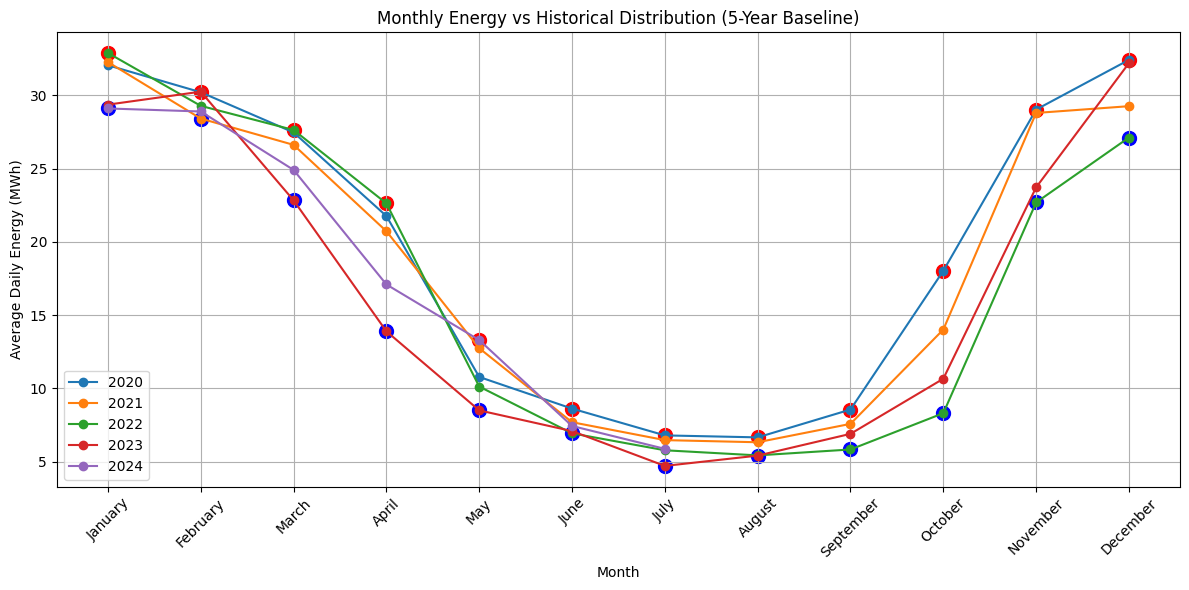

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Monthly mean per year
# -----------------------------
daily["month"] = daily["fecha"].dt.month
daily["month_name"] = daily["fecha"].dt.strftime("%B")

monthly_year = (
    daily.groupby(["year", "month", "month_name"])["total_daily_energy"]
    .mean()
    .reset_index()
)

# -----------------------------
# 2) Historical stats per month (5 years)
# -----------------------------
monthly_stats = (
    monthly_year.groupby("month")["total_daily_energy"]
    .agg(
        mean_hist="mean",
        std_hist="std",
        p75_hist=lambda x: x.quantile(0.75),
        p95_hist=lambda x: x.quantile(0.95),
        p10_hist=lambda x: x.quantile(0.10),
    )
    .reset_index()
)

monthly_year = monthly_year.merge(monthly_stats, on="month", how="left")

# -----------------------------
# 3) Detect peaks
# -----------------------------
monthly_year["high_peak"] = monthly_year["total_daily_energy"] > monthly_year["p95_hist"]
monthly_year["low_peak"]  = monthly_year["total_daily_energy"] < monthly_year["p10_hist"]

print("\n=== Historical Monthly Statistics ===")
print(monthly_stats)

# -----------------------------
# 4) Plot
# -----------------------------
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_year["month_name"] = pd.Categorical(
    monthly_year["month_name"],
    categories=month_order,
    ordered=True
)

monthly_year = monthly_year.sort_values(["year","month"])

plt.figure(figsize=(12,6))

for y in sorted(monthly_year["year"].unique()):
    temp = monthly_year[monthly_year["year"] == y]
    plt.plot(temp["month_name"], temp["total_daily_energy"], marker="o", label=str(y))

    # high peaks
    high = temp[temp["high_peak"]]
    plt.scatter(high["month_name"], high["total_daily_energy"], color="red", s=100)

    # low peaks
    low = temp[temp["low_peak"]]
    plt.scatter(low["month_name"], low["total_daily_energy"], color="blue", s=100)

plt.title("Monthly Energy vs Historical Distribution (5-Year Baseline)")
plt.xlabel("Month")
plt.ylabel("Average Daily Energy (MWh)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== Historical Monthly Baseline (5-year distribution) ===
 month  mean_hist  std_hist  p75_hist  p95_hist  p10_hist  min_hist  max_hist  n_years
     1     31.142     1.766    32.275    32.773    29.213    29.108    32.898        5
     2     29.416     0.809    30.216    30.248    28.612    28.419    30.256        5
     3     25.896     2.024    27.472    27.606    23.666    22.835    27.640        5
     4     19.219     3.649    21.763    22.453    15.171    13.891    22.626        5
     5     11.083     1.960    12.737    13.182     9.143     8.492    13.293        5
     6      7.545     0.666     7.683     8.426     6.985     6.924     8.612        5
     7      5.915     0.799     6.461     6.719     5.127     4.700     6.783        5
     8      5.946     0.634     6.399     6.599     5.407     5.402     6.649        4
     9      7.208     1.148     7.815     8.403     6.142     5.822     8.549        4
    10     12.746     4.226    15.013    17.420     9.005     8.300    

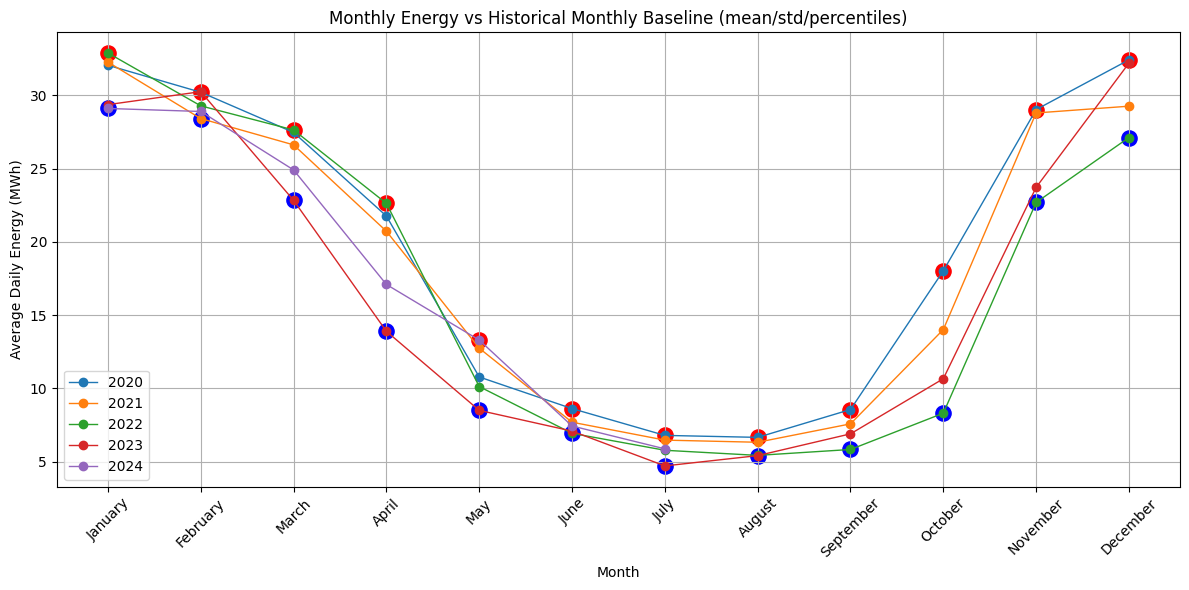

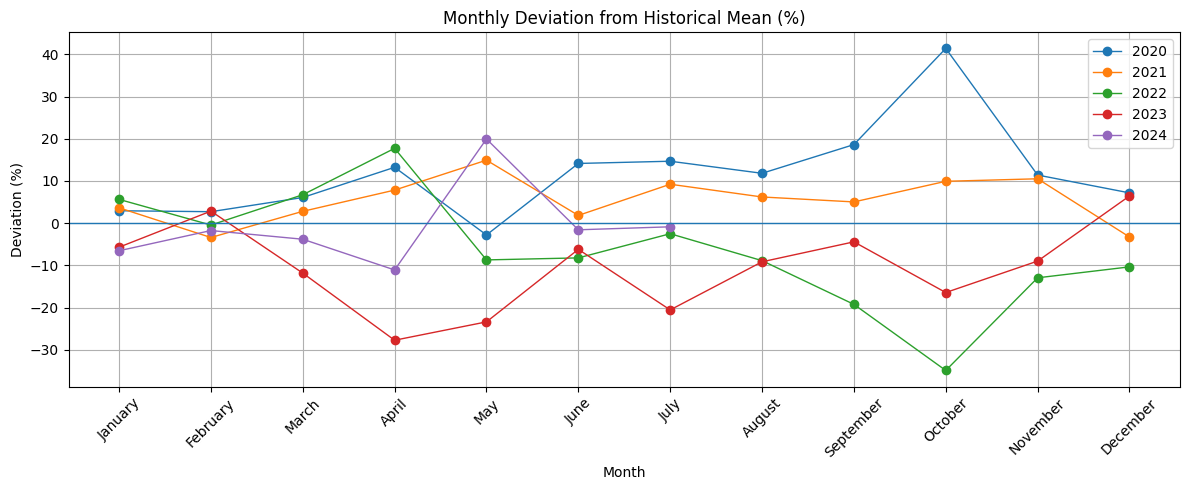

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
P75 = 0.75
P95 = 0.95
P10 = 0.10

Z_HIGH = 2.0   # >=2 sigma = very high
Z_CRIT = 3.0   # >=3 sigma = critical
Z_LOW  = -2.0  # <=-2 sigma = very low

# -----------------------------
# 1) Monthly mean per year (from daily)
# -----------------------------
daily = daily.copy()
daily["year"] = daily["fecha"].dt.year
daily["month"] = daily["fecha"].dt.month
daily["month_name"] = daily["fecha"].dt.strftime("%B")

monthly_year = (
    daily.groupby(["year","month","month_name"], as_index=False)["total_daily_energy"]
    .mean()
    .rename(columns={"total_daily_energy":"avg_daily_energy_month"})
)

# -----------------------------
# 2) Historical stats per month (using all years you have)
# -----------------------------
monthly_stats = (
    monthly_year.groupby("month")["avg_daily_energy_month"]
    .agg(
        mean_hist="mean",
        std_hist="std",
        p75_hist=lambda x: float(x.quantile(P75)),
        p95_hist=lambda x: float(x.quantile(P95)),
        p10_hist=lambda x: float(x.quantile(P10)),
        min_hist="min",
        max_hist="max",
        n_years="count"
    )
    .reset_index()
)

monthly_year = monthly_year.merge(monthly_stats, on="month", how="left")

# -----------------------------
# 3) Z-score + deviation %
# -----------------------------
# Avoid division by zero if std_hist == 0
monthly_year["std_hist_safe"] = monthly_year["std_hist"].replace(0, np.nan)

monthly_year["z_score"] = (
    (monthly_year["avg_daily_energy_month"] - monthly_year["mean_hist"]) / monthly_year["std_hist_safe"]
)

monthly_year["deviation_pct"] = 100 * (
    (monthly_year["avg_daily_energy_month"] - monthly_year["mean_hist"]) / monthly_year["mean_hist"]
)

# -----------------------------
# 4) Peak flags (percentiles) + severity labels
# -----------------------------
monthly_year["high_peak_p95"] = monthly_year["avg_daily_energy_month"] > monthly_year["p95_hist"]
monthly_year["high_peak_p75"] = monthly_year["avg_daily_energy_month"] > monthly_year["p75_hist"]
monthly_year["low_peak_p10"]  = monthly_year["avg_daily_energy_month"] < monthly_year["p10_hist"]

def severity(row):
    z = row["z_score"]
    if pd.isna(z):
        return "Unknown"

    if z >= Z_CRIT:
        return "Critical (very high)"
    if z >= Z_HIGH:
        return "Very High"
    if z >= 1.0:
        return "High"
    if z <= Z_LOW:
        return "Very Low"
    if z <= -1.0:
        return "Low"
    return "Normal"

monthly_year["severity"] = monthly_year.apply(severity, axis=1)

# -----------------------------
# 5) Print tables
# -----------------------------
print("\n=== Historical Monthly Baseline (5-year distribution) ===")
print(monthly_stats.round(3).to_string(index=False))

cols_out = [
    "year","month","month_name",
    "avg_daily_energy_month",
    "mean_hist","std_hist","p75_hist","p95_hist","p10_hist",
    "z_score","deviation_pct",
    "high_peak_p95","low_peak_p10","severity"
]
print("\n=== Monthly comparison vs baseline (sample) ===")
print(monthly_year[cols_out].sort_values(["year","month"]).head(24).round(3).to_string(index=False))

# Ranking: most extreme high months
rank_high = monthly_year.sort_values("z_score", ascending=False).head(10)[cols_out]
print("\n=== TOP 10 High months (by Z-score) ===")
print(rank_high.round(3).to_string(index=False))

# Ranking: most extreme low months
rank_low = monthly_year.sort_values("z_score", ascending=True).head(10)[cols_out]
print("\n=== TOP 10 Low months (by Z-score) ===")
print(rank_low.round(3).to_string(index=False))

# -----------------------------
# 6) Plot (months on X)
# -----------------------------
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly_year["month_name"] = pd.Categorical(monthly_year["month_name"], categories=month_order, ordered=True)
monthly_year = monthly_year.sort_values(["year","month"])

plt.figure(figsize=(12,6))

for y in sorted(monthly_year["year"].unique()):
    temp = monthly_year[monthly_year["year"] == y]
    plt.plot(temp["month_name"], temp["avg_daily_energy_month"], marker="o", linewidth=1, label=str(y))

    # High peaks (P95) in red
    high = temp[temp["high_peak_p95"]]
    plt.scatter(high["month_name"], high["avg_daily_energy_month"], color="red", s=120)

    # Low peaks (P10) in blue
    low = temp[temp["low_peak_p10"]]
    plt.scatter(low["month_name"], low["avg_daily_energy_month"], color="blue", s=120)

plt.title("Monthly Energy vs Historical Monthly Baseline (mean/std/percentiles)")
plt.xlabel("Month")
plt.ylabel("Average Daily Energy (MWh)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Optional plot: deviation %
# -----------------------------
plt.figure(figsize=(12,5))
for y in sorted(monthly_year["year"].unique()):
    temp = monthly_year[monthly_year["year"] == y]
    plt.plot(temp["month_name"], temp["deviation_pct"], marker="o", linewidth=1, label=str(y))

plt.axhline(0, linewidth=1)
plt.title("Monthly Deviation from Historical Mean (%)")
plt.xlabel("Month")
plt.ylabel("Deviation (%)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# =========================
# LOAD TEMPERATURE FILES
# =========================

FILE_TS_F1 = "TEMPERATURA IMPULS FASE II (15 minuto).csv"
FILE_TS_F2 = "Tª Impulsión Caldera gas 1 (15 minuto).csv"

def load_temp(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(",", ".", regex=False)
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    df = df.dropna(subset=["fecha","valor"])
    return df[["fecha","valor"]]

ts_f1 = load_temp(FILE_TS_F1).rename(columns={"valor":"ts_f1"})
ts_f2 = load_temp(FILE_TS_F2).rename(columns={"valor":"ts_f2"})

# =========================
# RESAMPLE TO DAILY
# =========================

ts_f1_daily = ts_f1.set_index("fecha").resample("1D").mean().reset_index()
ts_f2_daily = ts_f2.set_index("fecha").resample("1D").mean().reset_index()

# =========================
# ENERGY (ya la tenías como daily)
# daily debe contener:
# fecha, total_daily_energy
# =========================

dataset = daily.merge(ts_f1_daily, on="fecha", how="inner")
dataset = dataset.merge(ts_f2_daily, on="fecha", how="inner")

print(dataset.head())

       fecha  total_daily_energy  year  day_of_year  tramo  mean_tramo  \
0 2020-01-01               30.33  2020            1      0   31.713714   
1 2020-01-02               32.13  2020            2      0   31.713714   
2 2020-01-03               31.20  2020            3      0   31.713714   
3 2020-01-04               28.17  2020            4      0   31.713714   
4 2020-01-05               30.87  2020            5      0   31.713714   

   p75_tramo  is_peak  month month_name      ts_f1      ts_f2  
0     32.855    False      1    January  78.015104  73.262292  
1     32.855    False      1    January  78.674792  71.421354  
2     32.855    False      1    January  78.620000  70.876875  
3     32.855    False      1    January  78.741979  71.401250  
4     32.855    False      1    January  78.680729  70.294167  


In [ ]:
dataset["year"] = dataset["fecha"].dt.year

In [ ]:
train = dataset[dataset["year"].isin([2020,2021,2022])].copy()
test  = dataset[dataset["year"].isin([2023,2024])].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1096
Test size: 412


CSV files found: ['Potencia Contador Energía Calderas Gas (15 minuto).csv', '20260302 Weather History Hourly 41.6543639,-4.7222733 20230101-20231231 - Sheet1.csv', 'Tª Impulsión Caldera gas 1 (15 minuto).csv', 'Tª Retorno Contador Energía Fase 1 Central.csv', '20260302 Weather History Hourly 41.6543639,-4.7222733 20200101-20201231 - Sheet1.csv', 'Energía Contador Energía Fase 2 Central.csv', 'Potencia Contador Energía Fase 2 (15 minuto).csv', 'TEMPERATURA IMPULS FASE II (15 minuto).csv', '20260302 Weather History Hourly 41.6543639,-4.7222733 20210101-20211231 - Sheet1.csv', 'Energía Contador Energía Fase 1 Central.csv', 'Tª Retorno Contador Energía Fase 2 Central (15 minuto).csv']
Energy daily sample:
       fecha  daily_energy        date
0 2023-01-01         20.83  2023-01-01
1 2023-01-02         25.12  2023-01-02
2 2023-01-03         28.71  2023-01-03
3 2023-01-04         31.79  2023-01-04
4 2023-01-05         32.34  2023-01-05

Weather columns: ['siteId', 'latitude', 'longitude', '

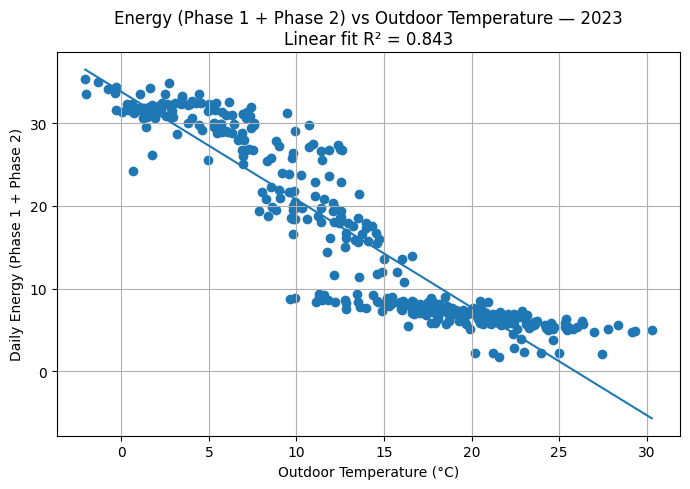


Linear model:
DailyEnergy = 33.804 + (-1.304) * T_out


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ==============================
# CONFIG
# ==============================
YEAR = 2023

VAR_F1 = "Energía Contador Energía Fase 1 Central"
VAR_F2 = "Energía Contador Energía Fase 2 Central"

WEATHER_FILE = "20260302 Weather History Hourly 41.6543639,-4.7222733 20230101-20231231 - Sheet1.csv"

# ==============================
# 1) LOAD ENERGY CSVs (all .csv in folder, then filter by 'variable')
#    Expected columns: endpoint, id, variable, fecha, valor
# ==============================
files = [f for f in os.listdir() if f.lower().endswith(".csv")]
print("CSV files found:", files)

dfs = []
for f in files:
    # Skip the weather file when loading energy
    if f == WEATHER_FILE:
        continue

    df = pd.read_csv(f)
    df.columns = df.columns.str.lower().str.strip()

    # Only keep files that look like the energy export structure
    if not {"fecha", "valor"}.issubset(set(df.columns)):
        continue

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # Convert Spanish decimal comma to dot
    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    dfs.append(df)

if not dfs:
    raise ValueError("No energy CSVs loaded. Check that your energy CSVs are in the same folder and have columns: fecha, valor, variable.")

df = pd.concat(dfs, ignore_index=True)
df = df.dropna(subset=["fecha", "valor"])

# Filter only the target year
df = df[df["fecha"].dt.year == YEAR].copy()

# Ensure 'variable' exists for filtering
if "variable" not in df.columns:
    raise ValueError("Column 'variable' not found in energy CSVs. Your energy files must contain a 'variable' column to filter Phase 1/2 energy.")

# ==============================
# 2) FILTER PHASE 1 & PHASE 2 ENERGY (accumulated -> diff)
# ==============================
f1 = df[df["variable"].astype(str).str.contains(VAR_F1, case=False, na=False)].copy()
f2 = df[df["variable"].astype(str).str.contains(VAR_F2, case=False, na=False)].copy()

if f1.empty or f2.empty:
    raise ValueError(
        "Could not find Phase 1 or Phase 2 energy variables in column 'variable'.\n"
        f"Looking for:\n- {VAR_F1}\n- {VAR_F2}"
    )

f1 = f1.sort_values("fecha")
f2 = f2.sort_values("fecha")

# Accumulated counters -> interval energy
f1["energy_f1"] = f1["valor"].diff()
f2["energy_f2"] = f2["valor"].diff()

# Remove resets/negatives
f1 = f1[f1["energy_f1"] >= 0].dropna(subset=["energy_f1"])
f2 = f2[f2["energy_f2"] >= 0].dropna(subset=["energy_f2"])

# Merge on timestamp
energy = pd.merge(
    f1[["fecha", "energy_f1"]],
    f2[["fecha", "energy_f2"]],
    on="fecha",
    how="inner"
)

energy["total_energy_interval"] = energy["energy_f1"] + energy["energy_f2"]

# Daily energy (sum of interval energy per day)
energy_daily = (
    energy.set_index("fecha")[["total_energy_interval"]]
    .resample("1D")
    .sum()
    .dropna()
    .reset_index()
)
energy_daily["date"] = energy_daily["fecha"].dt.date
energy_daily.rename(columns={"total_energy_interval": "daily_energy"}, inplace=True)

print("Energy daily sample:")
print(energy_daily.head())

# ==============================
# 3) LOAD WEATHER HISTORY (hourly) and compute daily mean temperature
# ==============================
wx = pd.read_csv(WEATHER_FILE)
wx.columns = [c.strip() for c in wx.columns]
print("\nWeather columns:", wx.columns.tolist())

# Auto-detect datetime column
dt_col = None
for c in wx.columns:
    cl = c.lower()
    if any(k in cl for k in ["validtimelocal", "datetime", "timestamp", "date", "time", "fecha"]):
        dt_col = c
        break
if dt_col is None:
    raise ValueError(f"Could not detect a datetime column in weather file. Columns: {wx.columns.tolist()}")

wx["fecha"] = pd.to_datetime(wx[dt_col], errors="coerce")

# Auto-detect temperature column
temp_col = None
for c in wx.columns:
    cl = c.lower()
    if "temp" in cl or "temperature" in cl or "t2m" in cl:
        temp_col = c
        break
if temp_col is None:
    # fallback: pick a numeric column with most non-null values (excluding datetime)
    num_cols = wx.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        temp_col = sorted([(c, wx[c].notna().sum()) for c in num_cols], key=lambda x: x[1], reverse=True)[0][0]
    else:
        raise ValueError("Could not detect a temperature column in the weather file.")

wx["t_out"] = pd.to_numeric(wx[temp_col], errors="coerce")

wx = wx.dropna(subset=["fecha", "t_out"])
wx = wx[wx["fecha"].dt.year == YEAR].copy()

# Daily mean outdoor temperature
wx_daily = (
    wx.set_index("fecha")[["t_out"]]
    .resample("1D")
    .mean()
    .dropna()
    .reset_index()
)
wx_daily["date"] = wx_daily["fecha"].dt.date

print("\nWeather daily sample:")
print(wx_daily.head())

# ==============================
# 4) MERGE ENERGY + WEATHER (daily)
# ==============================
data = pd.merge(
    energy_daily[["date", "daily_energy"]],
    wx_daily[["date", "t_out"]],
    on="date",
    how="inner"
).dropna()

print("\nMerged daily dataset sample:")
print(data.head())
print("\nRows merged:", len(data))

# ==============================
# 5) SCATTER PLOT + REGRESSION LINE
# ==============================
X = data[["t_out"]].values
y = data["daily_energy"].values

model = LinearRegression()
model.fit(X, y)

x_line = np.linspace(data["t_out"].min(), data["t_out"].max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

r2 = model.score(X, y)

plt.figure(figsize=(7,5))
plt.scatter(data["t_out"], data["daily_energy"])
plt.plot(x_line.flatten(), y_line)
plt.title(f"Energy (Phase 1 + Phase 2) vs Outdoor Temperature — {YEAR}\nLinear fit R² = {r2:.3f}")
plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Daily Energy (Phase 1 + Phase 2)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nLinear model:")
print("DailyEnergy = {:.3f} + ({:.3f}) * T_out".format(model.intercept_, model.coef_[0]))

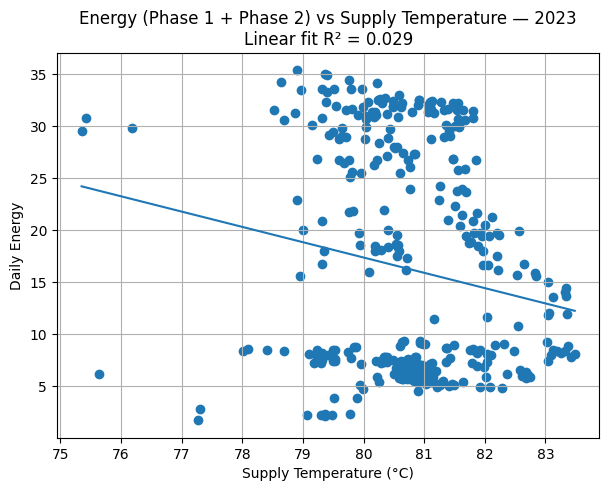

Model:
DailyEnergy = 135.042 + -1.471 * T_supply


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ==================================
# CONFIG
# ==================================
YEAR = 2023

VAR_F1 = "Energía Contador Energía Fase 1 Central"
VAR_F2 = "Energía Contador Energía Fase 2 Central"

SUPPLY_FILE = "TEMPERATURA IMPULS FASE II (15 minuto).csv"
# Si quieres usar la otra:
# SUPPLY_FILE = "Ta Impulsión Caldera gas 1 (15 minuto).csv"

# ==================================
# 1️⃣ LOAD ENERGY DATA
# ==================================
files = [f for f in os.listdir() if f.endswith(".csv")]

dfs = []
for f in files:
    if f == SUPPLY_FILE:
        continue

    df = pd.read_csv(f)
    df.columns = df.columns.str.lower().str.strip()

    if not {"fecha","valor"}.issubset(df.columns):
        continue

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = df[df["fecha"].dt.year == YEAR]

# ==================================
# 2️⃣ FILTER PHASE 1 & 2 (ACCUMULATIVE → DIFF)
# ==================================
f1 = df[df["variable"].str.contains(VAR_F1, case=False, na=False)].copy()
f2 = df[df["variable"].str.contains(VAR_F2, case=False, na=False)].copy()

f1 = f1.sort_values("fecha")
f2 = f2.sort_values("fecha")

f1["energy_f1"] = f1["valor"].diff()
f2["energy_f2"] = f2["valor"].diff()

f1 = f1[f1["energy_f1"] >= 0]
f2 = f2[f2["energy_f2"] >= 0]

energy = pd.merge(
    f1[["fecha","energy_f1"]],
    f2[["fecha","energy_f2"]],
    on="fecha"
)

energy["total_energy"] = energy["energy_f1"] + energy["energy_f2"]

# Daily energy
energy_daily = (
    energy.set_index("fecha")["total_energy"]
    .resample("1D")
    .sum()
    .reset_index()
)

# ==================================
# 3️⃣ LOAD SUPPLY TEMPERATURE
# ==================================
ts = pd.read_csv(SUPPLY_FILE)
ts.columns = ts.columns.str.lower().str.strip()

ts["fecha"] = pd.to_datetime(ts["fecha"], errors="coerce")

ts["valor"] = (
    ts["valor"].astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)
ts["valor"] = pd.to_numeric(ts["valor"], errors="coerce")

ts = ts[ts["fecha"].dt.year == YEAR]

# Daily average supply temperature
ts_daily = (
    ts.set_index("fecha")["valor"]
    .resample("1D")
    .mean()
    .reset_index()
)

ts_daily.rename(columns={"valor":"t_supply"}, inplace=True)

# ==================================
# 4️⃣ MERGE ENERGY + SUPPLY TEMP
# ==================================
data = pd.merge(
    energy_daily,
    ts_daily,
    on="fecha",
    how="inner"
).dropna()

# ==================================
# 5️⃣ SCATTER PLOT + LINEAR FIT
# ==================================
X = data[["t_supply"]].values
y = data["total_energy"].values

model = LinearRegression()
model.fit(X, y)

x_line = np.linspace(data["t_supply"].min(), data["t_supply"].max(), 200).reshape(-1,1)
y_line = model.predict(x_line)

r2 = model.score(X, y)

plt.figure(figsize=(7,5))
plt.scatter(data["t_supply"], data["total_energy"])
plt.plot(x_line, y_line)

plt.title(f"Energy (Phase 1 + Phase 2) vs Supply Temperature — {YEAR}\nLinear fit R² = {r2:.3f}")
plt.xlabel("Supply Temperature (°C)")
plt.ylabel("Daily Energy")
plt.grid(True)
plt.show()

print("Model:")
print("DailyEnergy = {:.3f} + {:.3f} * T_supply".format(model.intercept_, model.coef_[0]))


In [ ]:
TRAIN_YEARS = [2023]

In [ ]:
df = df[df["fecha"].dt.year == 2023]
print("Years in dataset:", dataset["year"].unique())
print("Rows per year:")
print(dataset.groupby("year").size())


Years in dataset: [2023 2024]
Rows per year:
year
2023    364
2024      1
dtype: int64


Train rows: 364
R2 (train): 0.8430488917870393
Estimated supply curve: T_supply ≈ 80.37 + (0.03) * T_out

=== 15-Day Forecast Table ===
                    fecha  t_out  t_supply  energy_forecast
2026-03-02 00:00:00+01:00 12.167    80.718           17.933
2026-03-03 00:00:00+01:00 11.333    80.694           19.020
2026-03-04 00:00:00+01:00 11.792    80.707           18.422
2026-03-05 00:00:00+01:00 10.708    80.676           19.836
2026-03-06 00:00:00+01:00  8.250    80.606           23.043
2026-03-07 00:00:00+01:00  8.708    80.619           22.445
2026-03-08 00:00:00+01:00  8.458    80.612           22.772
2026-03-09 00:00:00+01:00  8.375    80.609           22.880
2026-03-10 00:00:00+01:00  7.958    80.597           23.424
2026-03-11 00:00:00+01:00  8.667    80.618           22.500
2026-03-12 00:00:00+01:00  9.792    80.650           21.032
2026-03-13 00:00:00+01:00 10.167    80.661           20.542
2026-03-14 00:00:00+01:00  9.625    80.645           21.249
2026-03-15 00:00:00+01:0

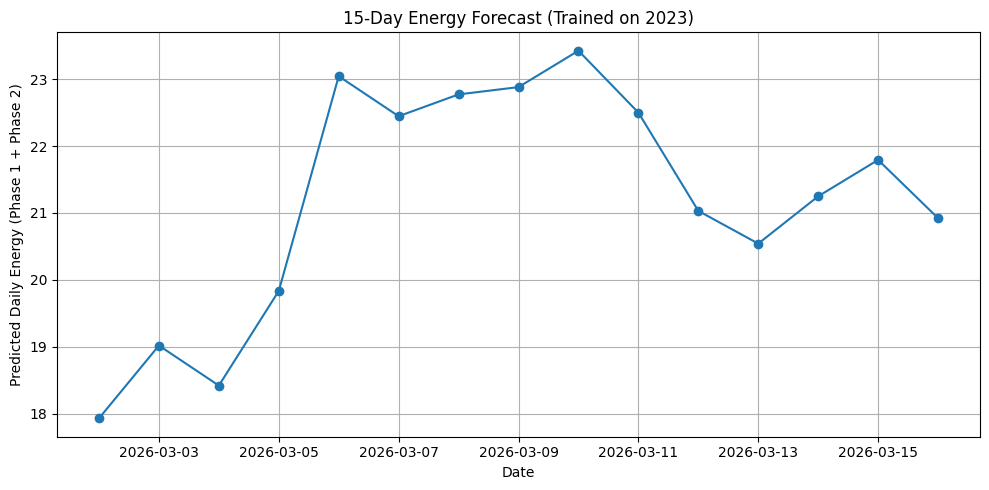

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# CONFIG
# =========================
TRAIN_YEAR = 2023
FORECAST_FILE = "20260302 Weather Forecast Hourly 41.6543639,-4.7222733 - Sheet1.csv"

# =========================
# 1) Train model with 2023
# dataset debe existir ya con columnas: fecha, daily_energy, t_out, t_supply
# =========================
hist = dataset.copy()
hist["year"] = hist["fecha"].dt.year

train = hist[hist["year"] == TRAIN_YEAR].dropna(subset=["daily_energy","t_out","t_supply"]).copy()
print("Train rows:", len(train))

if len(train) == 0:
    raise ValueError("No hay datos de entrenamiento en 2023 dentro de dataset. Revisa dataset['year'].unique() y que tenga t_out y t_supply.")

# Energy model: daily_energy = f(t_out, t_supply)
energy_model = LinearRegression()
energy_model.fit(train[["t_out","t_supply"]], train["daily_energy"])

print("R2 (train):", energy_model.score(train[["t_out","t_supply"]], train["daily_energy"]))

# =========================
# 2) Learn supply curve from 2023: t_supply = a + b * t_out
# =========================
curve_model = LinearRegression()
curve_model.fit(train[["t_out"]], train["t_supply"])

a_curve = curve_model.intercept_
b_curve = curve_model.coef_[0]

print(f"Estimated supply curve: T_supply ≈ {a_curve:.2f} + ({b_curve:.2f}) * T_out")

# =========================
# 3) Load Weather Forecast (hourly) -> daily mean temperature
# =========================
wx = pd.read_csv(FORECAST_FILE)
wx.columns = [str(c).strip() for c in wx.columns]

# Detect datetime column
dt_col = None
for c in wx.columns:
    cl = c.lower()
    if any(k in cl for k in ["validtimelocal", "datetime", "timestamp", "date", "time", "fecha"]):
        dt_col = c
        break
if dt_col is None:
    raise ValueError(f"No se detecta columna datetime en el forecast. Columnas: {wx.columns.tolist()}")

# Detect temperature column
temp_col = None
for c in wx.columns:
    cl = c.lower()
    if "temp" in cl or "temperature" in cl:
        temp_col = c
        break
if temp_col is None:
    raise ValueError(f"No se detecta columna de temperatura en el forecast. Columnas: {wx.columns.tolist()}")

wx["fecha"] = pd.to_datetime(wx[dt_col], errors="coerce")
wx["t_out"] = pd.to_numeric(wx[temp_col], errors="coerce")
wx = wx.dropna(subset=["fecha","t_out"]).copy()

# Daily mean outdoor temperature
wx_daily = (
    wx.set_index("fecha")["t_out"]
    .resample("1D")
    .mean()
    .dropna()
    .reset_index()
)

# Next 15 days
wx_daily = wx_daily.head(15).copy()

# =========================
# 4) Estimate future supply temp using learned curve
# =========================
wx_daily["t_supply"] = a_curve + b_curve * wx_daily["t_out"]

# =========================
# 5) Predict energy for next 15 days
# =========================
wx_daily["energy_forecast"] = energy_model.predict(wx_daily[["t_out","t_supply"]])

# Table output
print("\n=== 15-Day Forecast Table ===")
print(wx_daily[["fecha","t_out","t_supply","energy_forecast"]].round(3).to_string(index=False))

# Plot
plt.figure(figsize=(10,5))
plt.plot(wx_daily["fecha"], wx_daily["energy_forecast"], marker="o")
plt.title("15-Day Energy Forecast (Trained on 2023)")
plt.xlabel("Date")
plt.ylabel("Predicted Daily Energy (Phase 1 + Phase 2)")
plt.grid(True)
plt.tight_layout()
plt.show()

Train rows: 364
R2 (train): 0.8430488917870393
Estimated supply curve: T_supply ≈ 80.37 + (0.03) * T_out

=== 15-Day Forecast Table ===
                    fecha  t_out  t_supply  energy_forecast
2026-03-02 00:00:00+01:00 12.167    80.718           17.933
2026-03-03 00:00:00+01:00 11.333    80.694           19.020
2026-03-04 00:00:00+01:00 11.792    80.707           18.422
2026-03-05 00:00:00+01:00 10.708    80.676           19.836
2026-03-06 00:00:00+01:00  8.250    80.606           23.043
2026-03-07 00:00:00+01:00  8.708    80.619           22.445
2026-03-08 00:00:00+01:00  8.458    80.612           22.772
2026-03-09 00:00:00+01:00  8.375    80.609           22.880
2026-03-10 00:00:00+01:00  7.958    80.597           23.424
2026-03-11 00:00:00+01:00  8.667    80.618           22.500
2026-03-12 00:00:00+01:00  9.792    80.650           21.032
2026-03-13 00:00:00+01:00 10.167    80.661           20.542
2026-03-14 00:00:00+01:00  9.625    80.645           21.249
2026-03-15 00:00:00+01:0

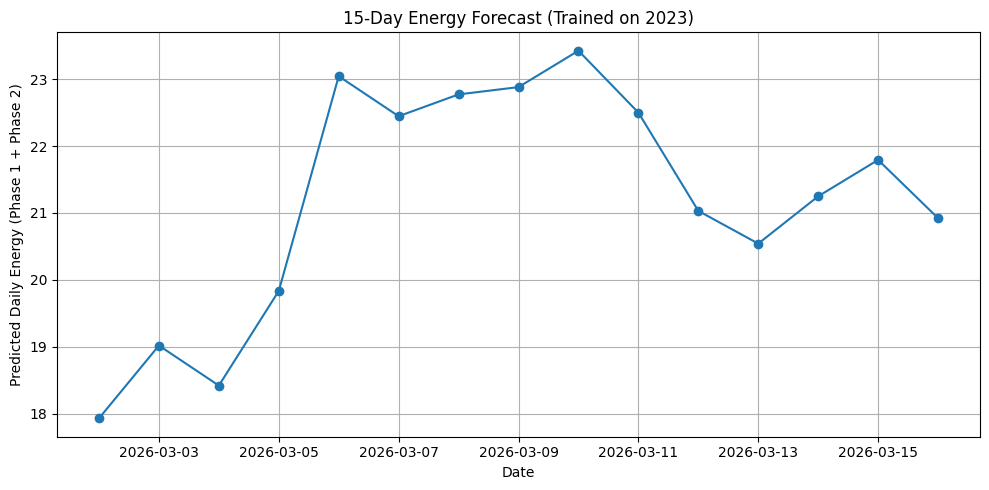

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# CONFIG
# =========================
TRAIN_YEAR = 2023
FORECAST_FILE = "20260302 Weather Forecast Hourly 41.6543639,-4.7222733 - Sheet1.csv"

# =========================
# 1) Train model with 2023
# dataset debe existir ya con columnas: fecha, daily_energy, t_out, t_supply
# =========================
hist = dataset.copy()
hist["year"] = hist["fecha"].dt.year

train = hist[hist["year"] == TRAIN_YEAR].dropna(subset=["daily_energy","t_out","t_supply"]).copy()
print("Train rows:", len(train))

if len(train) == 0:
    raise ValueError("No hay datos de entrenamiento en 2023 dentro de dataset. Revisa dataset['year'].unique() y que tenga t_out y t_supply.")

# Energy model: daily_energy = f(t_out, t_supply)
energy_model = LinearRegression()
energy_model.fit(train[["t_out","t_supply"]], train["daily_energy"])

print("R2 (train):", energy_model.score(train[["t_out","t_supply"]], train["daily_energy"]))

# =========================
# 2) Learn supply curve from 2023: t_supply = a + b * t_out
# =========================
curve_model = LinearRegression()
curve_model.fit(train[["t_out"]], train["t_supply"])

a_curve = curve_model.intercept_
b_curve = curve_model.coef_[0]

print(f"Estimated supply curve: T_supply ≈ {a_curve:.2f} + ({b_curve:.2f}) * T_out")

# =========================
# 3) Load Weather Forecast (hourly) -> daily mean temperature
# =========================
wx = pd.read_csv(FORECAST_FILE)
wx.columns = [str(c).strip() for c in wx.columns]

# Detect datetime column
dt_col = None
for c in wx.columns:
    cl = c.lower()
    if any(k in cl for k in ["validtimelocal", "datetime", "timestamp", "date", "time", "fecha"]):
        dt_col = c
        break
if dt_col is None:
    raise ValueError(f"No se detecta columna datetime en el forecast. Columnas: {wx.columns.tolist()}")

# Detect temperature column
temp_col = None
for c in wx.columns:
    cl = c.lower()
    if "temp" in cl or "temperature" in cl:
        temp_col = c
        break
if temp_col is None:
    raise ValueError(f"No se detecta columna de temperatura en el forecast. Columnas: {wx.columns.tolist()}")

wx["fecha"] = pd.to_datetime(wx[dt_col], errors="coerce")
wx["t_out"] = pd.to_numeric(wx[temp_col], errors="coerce")
wx = wx.dropna(subset=["fecha","t_out"]).copy()

# Daily mean outdoor temperature
wx_daily = (
    wx.set_index("fecha")["t_out"]
    .resample("1D")
    .mean()
    .dropna()
    .reset_index()
)

# Next 15 days
wx_daily = wx_daily.head(15).copy()

# =========================
# 4) Estimate future supply temp using learned curve
# =========================
wx_daily["t_supply"] = a_curve + b_curve * wx_daily["t_out"]

# =========================
# 5) Predict energy for next 15 days
# =========================
wx_daily["energy_forecast"] = energy_model.predict(wx_daily[["t_out","t_supply"]])

# Table output
print("\n=== 15-Day Forecast Table ===")
print(wx_daily[["fecha","t_out","t_supply","energy_forecast"]].round(3).to_string(index=False))

# Plot
plt.figure(figsize=(10,5))
plt.plot(wx_daily["fecha"], wx_daily["energy_forecast"], marker="o")
plt.title("15-Day Energy Forecast (Trained on 2023)")
plt.xlabel("Date")
plt.ylabel("Predicted Daily Energy (Phase 1 + Phase 2)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

# ==============================
# CONFIGURATION
# ==============================
YEAR = 2023

VAR_F1 = "Energía Contador Energía Fase 1 Central"
VAR_F2 = "Energía Contador Energía Fase 2 Central"

WEATHER_FILE = "20260302 Weather History Hourly 41.6543639,-4.7222733 20230101-20231231 - Sheet1.csv"

# Thresholds (percentiles)
ENERGY_PERCENTILE = 0.75   # 0.95 for peak detection
TOUT_PERCENTILE   = 0.75

# ==============================
# HELPER FUNCTIONS
# ==============================
def clean_spanish_number(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(".", "", regex=False)
              .str.replace(",", ".", regex=False)
              .str.strip(),
        errors="coerce"
    )

def detect_datetime_column(columns):
    for c in columns:
        cl = c.lower()
        if any(k in cl for k in ["validtimelocal","datetime","timestamp","date","time","fecha"]):
            return c
    return None

def detect_temperature_column(columns):
    for c in columns:
        if "temp" in c.lower():
            return c
    return None

# ==============================
# 1️⃣ LOAD ENERGY DATA
# ==============================
files = [f for f in os.listdir() if f.lower().endswith(".csv") and f != WEATHER_FILE]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.lower().str.strip()

    if not {"fecha","valor","variable"}.issubset(df.columns):
        continue

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df["valor"] = clean_spanish_number(df["valor"])
    df = df.dropna(subset=["fecha","valor"])
    dfs.append(df)

if not dfs:
    raise ValueError("No energy CSV files were loaded.")

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all[df_all["fecha"].dt.year == YEAR].copy()

# Filter Phase 1 & Phase 2
f1 = df_all[df_all["variable"].str.contains(VAR_F1, case=False, na=False)].copy().sort_values("fecha")
f2 = df_all[df_all["variable"].str.contains(VAR_F2, case=False, na=False)].copy().sort_values("fecha")

# Convert cumulative → interval energy
f1["energy_f1"] = f1["valor"].diff()
f2["energy_f2"] = f2["valor"].diff()

f1 = f1[(f1["energy_f1"] >= 0)].dropna(subset=["energy_f1"])
f2 = f2[(f2["energy_f2"] >= 0)].dropna(subset=["energy_f2"])

energy = pd.merge(f1[["fecha","energy_f1"]], f2[["fecha","energy_f2"]], on="fecha")
energy["total_energy_interval"] = energy["energy_f1"] + energy["energy_f2"]

# Daily energy
energy_daily = (
    energy.set_index("fecha")["total_energy_interval"]
          .resample("1D")
          .sum()
          .dropna()
          .reset_index()
          .rename(columns={"total_energy_interval":"daily_energy"})
)

# ==============================
# 2️⃣ LOAD WEATHER DATA
# ==============================
wx = pd.read_csv(WEATHER_FILE)
wx.columns = [str(c).strip() for c in wx.columns]

dt_col = detect_datetime_column(wx.columns)
temp_col = detect_temperature_column(wx.columns)

if dt_col is None or temp_col is None:
    raise ValueError("Weather file does not contain recognizable datetime or temperature columns.")

wx["fecha"] = pd.to_datetime(wx[dt_col], errors="coerce")
wx["t_out"] = pd.to_numeric(wx[temp_col], errors="coerce")
wx = wx.dropna(subset=["fecha","t_out"])
wx = wx[wx["fecha"].dt.year == YEAR]

t_out_daily = (
    wx.set_index("fecha")["t_out"]
      .resample("1D")
      .mean()
      .dropna()
      .reset_index()
)

# ==============================
# 3️⃣ MERGE + THRESHOLD LOGIC
# ==============================
data = pd.merge(energy_daily, t_out_daily, on="fecha").dropna()

energy_threshold = data["daily_energy"].quantile(ENERGY_PERCENTILE)
tout_threshold = data["t_out"].quantile(TOUT_PERCENTILE)

data["high_energy"] = data["daily_energy"] >= energy_threshold
data["high_temperature"] = data["t_out"] >= tout_threshold
data["alert"] = data["high_energy"] & data["high_temperature"]

print(f"Energy threshold (P{int(ENERGY_PERCENTILE*100)}): {energy_threshold:.2f}")
print(f"Outdoor temperature threshold (P{int(TOUT_PERCENTILE*100)}): {tout_threshold:.2f}")

# ==============================
# 4️⃣ PRINT ALERTS
# ==============================
alerts = data[data["alert"]]

if alerts.empty:
    print("\n✅ No days detected with High Energy Demand AND High Outdoor Temperature.")
else:
    print(f"\n⚠️ {len(alerts)} days detected with High Energy Demand AND High Outdoor Temperature:\n")

    for _, row in alerts.iterrows():
        print("----------------------------------------------------")
        print(f"Date: {row['fecha'].strftime('%Y-%m-%d')}")
        print(f"Outdoor Temperature: {row['t_out']:.1f} °C (above threshold)")
        print(f"Energy Demand: {row['daily_energy']:.2f} (above threshold)")
        print("\n👉 Suggested Action:")
        print("• Investigate abnormal demand under warm conditions.")
        print("• Review supply temperature setpoints.")
        print("• Check control strategy and possible inefficiencies.")
        print("----------------------------------------------------\n")

Energy threshold (P75): 27.44
Outdoor temperature threshold (P75): 19.53

✅ No days detected with High Energy Demand AND High Outdoor Temperature.


Train rows: 1082 Test rows: 365
MAE (2023):  1.342
RMSE (2023): 2.346


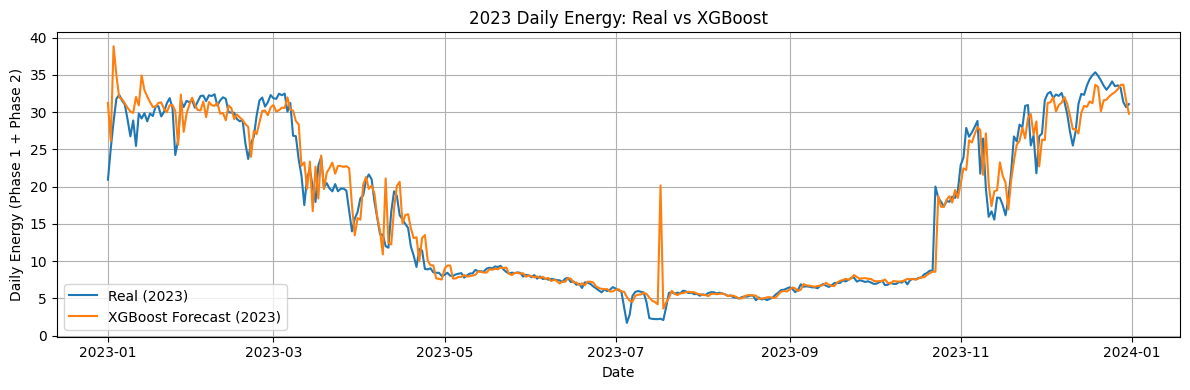


=== 15-day forecast table ===
                    fecha  t_out  energy_forecast
2026-03-02 00:00:00+01:00 12.167           10.429
2026-03-03 00:00:00+01:00 11.333           13.096
2026-03-04 00:00:00+01:00 11.792           12.861
2026-03-05 00:00:00+01:00 10.708           13.026
2026-03-06 00:00:00+01:00  8.250           12.316
2026-03-07 00:00:00+01:00  8.708           12.124
2026-03-08 00:00:00+01:00  8.458           12.109
2026-03-09 00:00:00+01:00  8.375           17.822
2026-03-10 00:00:00+01:00  7.958           18.623
2026-03-11 00:00:00+01:00  8.667           18.586
2026-03-12 00:00:00+01:00  9.792           18.391
2026-03-13 00:00:00+01:00 10.167           16.331
2026-03-14 00:00:00+01:00  9.625           12.778
2026-03-15 00:00:00+01:00  9.208           11.450
2026-03-16 00:00:00+01:00  9.875           17.289


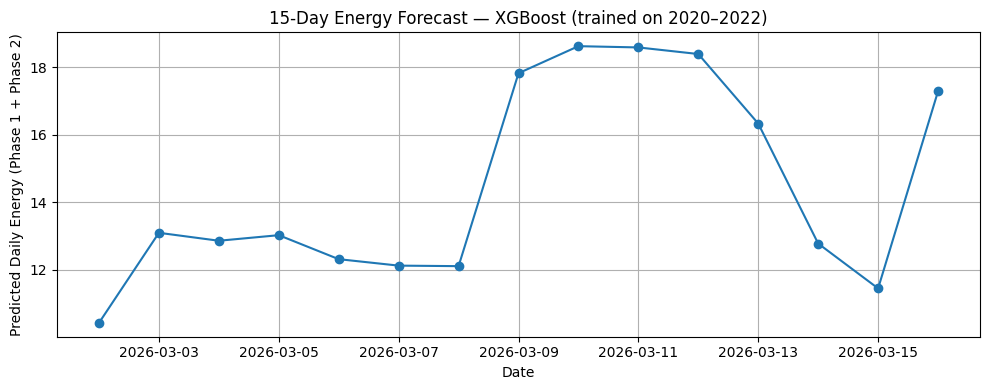

In [ ]:
# ==============================
# XGBoost Daily Forecast (Fixed RMSE)
# Train: 2020-2022
# Test:  2023
# Forecast: next 15 days using weather forecast CSV
# ==============================

!pip -q install xgboost

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================
# CONFIG
# ==============================
TRAIN_YEARS = [2020, 2021, 2022]
TEST_YEAR   = 2023

VAR_F1 = "Energía Contador Energía Fase 1 Central"
VAR_F2 = "Energía Contador Energía Fase 2 Central"

# Weather files (adjust if your filenames differ)
WEATHER_HISTORY_2023 = "20260302 Weather History Hourly 41.6543639,-4.7222733 20230101-20231231 - Sheet1.csv"
WEATHER_FORECAST_15D = "20260302 Weather Forecast Hourly 41.6543639,-4.7222733 - Sheet1.csv"

# ==============================
# Helpers
# ==============================
def clean_spanish_number(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str)
         .str.replace(".", "", regex=False)
         .str.replace(",", ".", regex=False)
         .str.strip(),
        errors="coerce"
    )

def detect_datetime_col(cols):
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in ["validtimelocal","datetime","timestamp","date","time","fecha"]):
            return c
    return None

def detect_temp_col(cols):
    for c in cols:
        cl = c.lower()
        if "temperature" in cl or cl == "temp" or "temp" in cl:
            return c
    return None

# ==============================
# 1) Load energy CSVs and build DAILY energy (F1+F2)
# ==============================
files = [f for f in os.listdir() if f.lower().endswith(".csv")]

dfs = []
for f in files:
    # skip weather files if they are in the same folder
    if f in [WEATHER_HISTORY_2023, WEATHER_FORECAST_15D]:
        continue

    df = pd.read_csv(f)
    df.columns = df.columns.str.lower().str.strip()

    if not {"fecha","valor","variable"}.issubset(df.columns):
        continue

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df["valor"] = clean_spanish_number(df["valor"])
    df = df.dropna(subset=["fecha","valor"])
    dfs.append(df)

if not dfs:
    raise ValueError("No energy CSV files found with columns: fecha, valor, variable.")

raw = pd.concat(dfs, ignore_index=True)

# Filter variables
f1 = raw[raw["variable"].astype(str).str.contains(VAR_F1, case=False, na=False)].copy().sort_values("fecha")
f2 = raw[raw["variable"].astype(str).str.contains(VAR_F2, case=False, na=False)].copy().sort_values("fecha")

if f1.empty or f2.empty:
    raise ValueError("Phase 1 or Phase 2 energy variable not found. Check VAR_F1 / VAR_F2 names.")

# cumulative -> interval diff
f1["e_f1"] = f1["valor"].diff()
f2["e_f2"] = f2["valor"].diff()

# remove negative/reset
f1 = f1[(f1["e_f1"] >= 0)].dropna(subset=["e_f1"])
f2 = f2[(f2["e_f2"] >= 0)].dropna(subset=["e_f2"])

energy = pd.merge(f1[["fecha","e_f1"]], f2[["fecha","e_f2"]], on="fecha", how="inner")
energy["energy_interval"] = energy["e_f1"] + energy["e_f2"]

daily_energy = (
    energy.set_index("fecha")["energy_interval"]
    .resample("1D").sum()
    .dropna()
    .reset_index()
    .rename(columns={"energy_interval":"daily_energy"})
)

daily_energy["year"] = daily_energy["fecha"].dt.year

# ==============================
# 2) Load weather history (2023) and make daily T_out
# ==============================
wx = pd.read_csv(WEATHER_HISTORY_2023)
wx.columns = [str(c).strip() for c in wx.columns]

dt_col = detect_datetime_col(wx.columns)
temp_col = detect_temp_col(wx.columns)

if dt_col is None or temp_col is None:
    raise ValueError(f"Weather history columns not detected. Columns: {wx.columns.tolist()}")

wx["fecha"] = pd.to_datetime(wx[dt_col], errors="coerce")
wx["t_out"] = pd.to_numeric(wx[temp_col], errors="coerce")
wx = wx.dropna(subset=["fecha","t_out"])

t_out_daily_2023 = (
    wx.set_index("fecha")["t_out"]
    .resample("1D").mean()
    .dropna()
    .reset_index()
)

# Merge daily energy with weather (left join, then interpolate)
data = pd.merge(daily_energy, t_out_daily_2023, on="fecha", how="left")
data = data.sort_values("fecha").reset_index(drop=True)
data["t_out"] = data["t_out"].interpolate(limit_direction="both")

# ==============================
# 3) Feature engineering (lags + rolling + calendar)
# ==============================
data["dow"] = data["fecha"].dt.dayofweek
data["month"] = data["fecha"].dt.month
data["doy"] = data["fecha"].dt.dayofyear

for lag in [1,2,7,14]:
    data[f"lag_{lag}"] = data["daily_energy"].shift(lag)

data["roll_3"] = data["daily_energy"].shift(1).rolling(3).mean()
data["roll_7"] = data["daily_energy"].shift(1).rolling(7).mean()

feat_cols = ["t_out","dow","month","doy","lag_1","lag_2","lag_7","lag_14","roll_3","roll_7"]
data_model = data.dropna(subset=feat_cols + ["daily_energy"]).copy()

# ==============================
# 4) Train/Test split
# ==============================
train = data_model[data_model["year"].isin(TRAIN_YEARS)].copy()
test  = data_model[data_model["year"] == TEST_YEAR].copy()

print("Train rows:", len(train), "Test rows:", len(test))

if len(train) == 0 or len(test) == 0:
    raise ValueError("Train or test dataset is empty. Check available years and merges.")

X_train, y_train = train[feat_cols], train["daily_energy"]
X_test,  y_test  = test[feat_cols],  test["daily_energy"]

# ==============================
# 5) Train XGBoost
# ==============================
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate on 2023 (FIXED RMSE)
pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print(f"MAE (2023):  {mae:.3f}")
print(f"RMSE (2023): {rmse:.3f}")

# Plot real vs predicted
plt.figure(figsize=(12,4))
plt.plot(test["fecha"], y_test.values, label="Real (2023)")
plt.plot(test["fecha"], pred_test, label="XGBoost Forecast (2023)")
plt.title("2023 Daily Energy: Real vs XGBoost")
plt.xlabel("Date")
plt.ylabel("Daily Energy (Phase 1 + Phase 2)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 6) Forecast next 15 days using WEATHER FORECAST
# ==============================
wx_fc = pd.read_csv(WEATHER_FORECAST_15D)
wx_fc.columns = [str(c).strip() for c in wx_fc.columns]

dt_col_fc = detect_datetime_col(wx_fc.columns)
temp_col_fc = detect_temp_col(wx_fc.columns)

if dt_col_fc is None or temp_col_fc is None:
    raise ValueError(f"Weather forecast columns not detected. Columns: {wx_fc.columns.tolist()}")

wx_fc["fecha"] = pd.to_datetime(wx_fc[dt_col_fc], errors="coerce")
wx_fc["t_out"] = pd.to_numeric(wx_fc[temp_col_fc], errors="coerce")
wx_fc = wx_fc.dropna(subset=["fecha","t_out"])

wx_fc_daily = (
    wx_fc.set_index("fecha")["t_out"]
    .resample("1D").mean()
    .dropna()
    .reset_index()
    .head(15)
)

# iterative forecasting (lags depend on previous predictions)
history = data.sort_values("fecha")[["fecha","daily_energy","t_out"]].dropna().copy().reset_index(drop=True)

future_preds = []

for i in range(len(wx_fc_daily)):
    future_date = wx_fc_daily.loc[i, "fecha"]
    future_tout = wx_fc_daily.loc[i, "t_out"]

    hist_series = history["daily_energy"].values

    row = {
        "t_out": future_tout,
        "dow": future_date.dayofweek,
        "month": future_date.month,
        "doy": future_date.dayofyear,
        "lag_1": hist_series[-1],
        "lag_2": hist_series[-2] if len(hist_series) >= 2 else hist_series[-1],
        "lag_7": hist_series[-7] if len(hist_series) >= 7 else hist_series[-1],
        "lag_14": hist_series[-14] if len(hist_series) >= 14 else hist_series[-1],
        "roll_3": np.mean(hist_series[-3:]) if len(hist_series) >= 3 else hist_series[-1],
        "roll_7": np.mean(hist_series[-7:]) if len(hist_series) >= 7 else hist_series[-1],
    }

    X_future = pd.DataFrame([row])[feat_cols]
    y_future = float(model.predict(X_future)[0])

    future_preds.append((future_date, future_tout, y_future))

    history = pd.concat([history, pd.DataFrame([{
        "fecha": future_date, "daily_energy": y_future, "t_out": future_tout
    }])], ignore_index=True)

forecast_df = pd.DataFrame(future_preds, columns=["fecha","t_out","energy_forecast"])

print("\n=== 15-day forecast table ===")
print(forecast_df.round(3).to_string(index=False))

plt.figure(figsize=(10,4))
plt.plot(forecast_df["fecha"], forecast_df["energy_forecast"], marker="o")
plt.title("15-Day Energy Forecast — XGBoost (trained on 2020–2022)")
plt.xlabel("Date")
plt.ylabel("Predicted Daily Energy (Phase 1 + Phase 2)")
plt.grid(True)
plt.tight_layout()
plt.show()